In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from te2rules.explainer import ModelExplainer
from sklearn.model_selection import train_test_split

In [2]:
TRAIN_MODEL = True
USE_SMOTE = True

TRAIN_CSV = '../../results/metrics.csv'

MODEL_OUTPUT_DIR = 'saved_model/'
MODEL_DIR = 'saved_model/'
OUTPUT_PNG = '../../results/acts_validation_predictions.png'

In [3]:


def engineer_features(df, target_col='is_high_risk'):
    df_fe = df.copy()

    df_fe['operator_operand_ratio'] = df_fe['halstead_operators'] / \
        (df_fe['halstead_operands'] + 1)
    df_fe['sloc_per_function'] = df_fe['loc_sloc'] / \
        (df_fe['nom_functions'] + 1)
    df_fe['complexity_per_function'] = df_fe['wmc_cyclomatic'] / \
        (df_fe['nom_functions'] + 1)
    df_fe['effort_per_volume'] = df_fe['halstead_effort'] / \
        (df_fe['halstead_volume'] + 1)
    df_fe['avg_exit_per_fn'] = df_fe['nexits_exit_sum'] / \
        (df_fe['nom_functions'] + 1)
    df_fe['cognitive_per_cyclomatic'] = df_fe['cognitive_sum'] / \
        (df_fe['cyclomatic_cyclomatic_sum'] + 1)

    for col in ['halstead_volume', 'halstead_effort', 'loc_sloc', 'loc_ploc', 'halstead_operators', 'halstead_operands']:
        df_fe[f'{col}_log'] = np.log1p(df_fe[col])

    df_fe['repo'] = df_fe['file_path'].str.split('__').str[0]

    exclude_cols = ['file_path', 'repo', target_col]
    feature_cols = [col for col in df_fe.columns if col not in exclude_cols]

    df_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_fe.dropna(inplace=True)

    X = df_fe[feature_cols].copy()
    X = X.select_dtypes(include=[np.number])
    X = X.fillna(X.median())

    y = df_fe[target_col].astype(str).str.lower()

    key_features = ['halstead_difficulty', 'halstead_effort', 'halstead_volume',
                    'wmc_cyclomatic', 'cyclomatic_cyclomatic', 'loc_sloc',
                    'nom_functions', 'cognitive']
    existing_features = [f for f in key_features if f in X.columns]

    poly = PolynomialFeatures(
        degree=2, include_bias=False, interaction_only=False)
    X_key = X[existing_features].copy()
    poly_features = poly.fit_transform(X_key)
    poly_feature_names = poly.get_feature_names_out(existing_features)

    for i, name in enumerate(poly_feature_names):
        clean_name = name.replace(' ', '_')
        X[f'poly_{clean_name}'] = poly_features[:, i]

    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X = X.fillna(X.median())

    return X, y, poly

In [4]:
def select_features(X, y, var_thresh=None, selector=None):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
    X_selected = X.drop(columns=to_drop)

    if var_thresh is None:
        var_thresh = VarianceThreshold(threshold=0.01)
        X_transformed = var_thresh.fit_transform(X_selected)
    else:
        X_transformed = var_thresh.transform(X_selected)

    X_selected = pd.DataFrame(
        X_transformed,
        columns=X_selected.columns[var_thresh.get_support()],
        index=X_selected.index
    )

    X_selected.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_selected = X_selected.fillna(X_selected.median())
    to_drop_nan = X_selected.columns[X_selected.isna().all()]
    if len(to_drop_nan) > 0:
        X_selected = X_selected.drop(columns=to_drop_nan)

    best_k = min(30, X_selected.shape[1])
    if selector is None:
        selector = SelectKBest(f_classif, k=best_k)
        X_final = pd.DataFrame(
            selector.fit_transform(X_selected, y),
            columns=[X_selected.columns[i]
                     for i in selector.get_support(indices=True)],
            index=X_selected.index
        )
    else:
        X_final = pd.DataFrame(
            selector.transform(X_selected),
            columns=[X_selected.columns[i]
                     for i in selector.get_support(indices=True)],
            index=X_selected.index
        )

    return X_final, var_thresh, selector

In [5]:
def train_model(X, y, model_type, use_smote, cv, le, output_dir):
    print(f"\n{'='*60}")
    print(f"{'SMOTE' if use_smote else 'NO SMOTE'} - {model_type.upper()}")
    print("="*60)

    if use_smote:
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            (model_type, DecisionTreeClassifier(random_state=42) if model_type == 'dt' else RandomForestClassifier(random_state=42))
        ])
    else:
        pipeline = Pipeline([
            (model_type, DecisionTreeClassifier(random_state=42) if model_type == 'dt' else RandomForestClassifier(random_state=42))
        ])

    if model_type == 'dt':
        param_grid = {
            f'{model_type}__max_depth': [3, 5, 7, 10, 15],
            f'{model_type}__min_samples_split': [5, 10, 20, 50],
            f'{model_type}__min_samples_leaf': [2, 5, 10, 20],
            f'{model_type}__criterion': ['gini', 'entropy'],
            f'{model_type}__class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}]
        }
    else:
        param_grid = {
            f'{model_type}__n_estimators': [100, 300, 500],
            f'{model_type}__max_depth': [7, 10, 15, 20, 30],
            f'{model_type}__min_samples_split': [5, 10],
            f'{model_type}__min_samples_leaf': [4, 8],
            f'{model_type}__max_features': ['sqrt', 'log2'],
            f'{model_type}__class_weight': ['balanced', {0: 1, 1: 3}, {0: 1, 1: 10}]
        }

    grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
    grid_search.fit(X, y)

    print(f"Best params: {grid_search.best_params_}")
    print(f"Best CV F1: {grid_search.best_score_:.4f}")

    clf = grid_search.best_estimator_

    cv_accuracy = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(clf, X, y, cv=cv, scoring='precision')
    cv_recall = cross_val_score(clf, X, y, cv=cv, scoring='recall')
    cv_f1 = cross_val_score(clf, X, y, cv=cv, scoring='f1')

    print(f"\n{model_type.upper()} 5-Fold CV Results:")
    print(f"Accuracy:  {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}")
    print(f"Precision: {cv_precision.mean():.4f} +/- {cv_precision.std():.4f}")
    print(f"Recall:    {cv_recall.mean():.4f} +/- {cv_recall.std():.4f}")
    print(f"F1 Score:  {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")

    cv_preds = cross_val_predict(clf, X, y, cv=cv)
    cv_cm = confusion_matrix(y, cv_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cv_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_type.upper()} CV Confusion Matrix ({("SMOTE" if use_smote else "NoSMOTE")})')
    smote_str = "smote" if use_smote else "no_smote"
    plt.savefig(f'{output_dir}/{model_type}_cv_confusion_matrix_{smote_str}.png', dpi=150)
    plt.show()

    if model_type == 'dt':
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': clf.named_steps['dt'].feature_importances_
        }).sort_values('importance', ascending=False)
    else:
        rf_for_importance = RandomForestClassifier(
            random_state=42,
            **{k.replace(f'{model_type}__', ''): v for k, v in grid_search.best_params_.items() if k.startswith(f'{model_type}__')}
        )
        rf_for_importance.fit(X, y)
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': rf_for_importance.feature_importances_
        }).sort_values('importance', ascending=False)

    print(f"\n{model_type.upper()} Feature Importances (top 15):")
    print(feature_importance.head(15))

    plt.figure(figsize=(10, 8))
    top15 = feature_importance.head(15).sort_values('importance', ascending=True)
    colors = sns.color_palette("coolwarm" if model_type == 'dt' else "viridis", 15)
    sns.barplot(x='importance', y='feature', data=top15, palette=colors)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'{model_type.upper()} Feature Importance Top 15 ({("SMOTE" if use_smote else "NoSMOTE")})')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/{model_type}_feature_importance_{smote_str}.png', dpi=150)
    plt.show()

    clf.fit(X, y)
    os.makedirs(output_dir, exist_ok=True)
    joblib.dump(clf, f'{output_dir}/{model_type}_model_{smote_str}.joblib')

    return clf, grid_search.best_params_, {
        'accuracy': cv_accuracy.mean(),
        'precision': cv_precision.mean(),
        'recall': cv_recall.mean(),
        'f1': cv_f1.mean(),
        'cm': cv_cm
    }

In [6]:
if TRAIN_MODEL:
    le = LabelEncoder()

    df_train = pd.read_csv(TRAIN_CSV)
    print(f"Training data: {df_train.shape[0]} samples")

Training data: 9297 samples


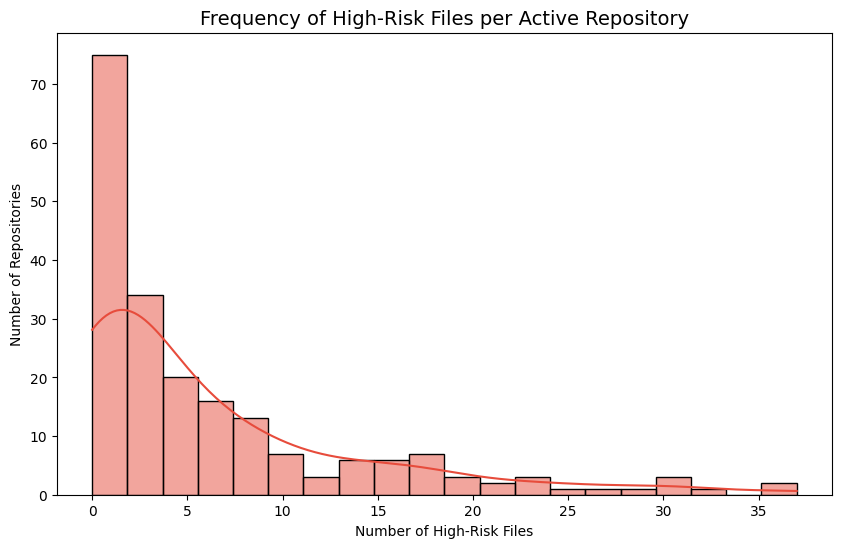

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(repo_stats[repo_stats['high_risk_files'] > -1]['high_risk_files'], 
             bins=20, color='#e74c3c', kde=True)
plt.title('Frequency of High-Risk Files per Active Repository', fontsize=14)
plt.xlabel('Number of High-Risk Files')
plt.ylabel('Number of Repositories')
plt.savefig('risk_frequency_histogram.png', dpi=150)

In [8]:
if TRAIN_MODEL:
    X_train_final, var_thresh, selector = select_features(
        X_train, y_train_encoded)
    print(f"Final feature count: {X_train_final.shape[1]}")
    print(f"Selected features: {list(X_train_final.columns)}")
    print(f"Training FE columns: {sorted(X_train_final.columns.tolist())}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
    joblib.dump(le, f'{MODEL_OUTPUT_DIR}/label_encoder.joblib')
    joblib.dump(var_thresh, f'{MODEL_OUTPUT_DIR}/var_thresh.joblib')
    joblib.dump(selector, f'{MODEL_OUTPUT_DIR}/selector.joblib')
    with open(f'{MODEL_OUTPUT_DIR}/selected_features.txt', 'w') as f:
        f.write('\n'.join(X_train_final.columns))

Final feature count: 30
Selected features: ['nargs_fn_nargs_sum', 'nargs_closure_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_max', 'nexits_exit', 'nexits_exit_sum', 'nexits_exit_avg', 'nexits_exit_max', 'cognitive', 'cognitive_sum', 'cognitive_avg', 'cognitive_min', 'cognitive_max', 'cyclomatic_cyclomatic_avg', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_difficulty', 'loc_blank', 'operator_operand_ratio', 'cognitive_per_cyclomatic', 'halstead_volume_log', 'loc_sloc_log', 'poly_halstead_difficulty_nom_functions', 'poly_halstead_effort_cyclomatic_cyclomatic', 'poly_halstead_effort_nom_functions', 'poly_halstead_volume_loc_sloc', 'poly_cyclomatic_cyclomatic_nom_functions', 'poly_nom_functions_cognitive']
Training FE columns: ['cognitive', 'cognitive_avg', 'cognitive_max', 'cognitive_min', 'cognitive_per_cyclomatic', 'cognitive_sum', 'cyclomatic_cyclomatic_avg', 'halstead_difficulty', 'halstead_operators', 'halstead_u_oper


BLOCK 1: DECISION TREE WITHOUT SMOTE

NO SMOTE - DT
Best params: {'dt__class_weight': {0: 1, 1: 5}, 'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_samples_leaf': 10, 'dt__min_samples_split': 50}
Best CV F1: 0.3497

DT 5-Fold CV Results:
Accuracy:  0.6947 +/- 0.0190
Precision: 0.2471 +/- 0.0148
Recall:    0.6000 +/- 0.0283
F1 Score:  0.3497 +/- 0.0160


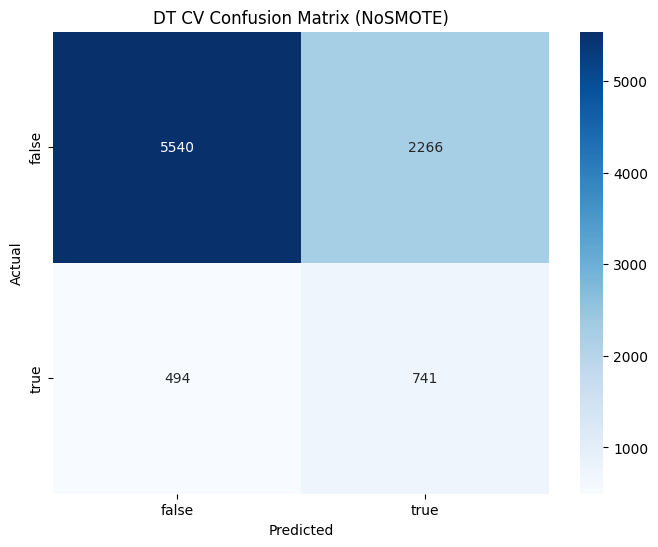


DT Feature Importances (top 15):
                                       feature  importance
25  poly_halstead_effort_cyclomatic_cyclomatic    0.208933
16                          halstead_operators    0.090380
2                           nargs_fn_nargs_avg    0.082716
20                      operator_operand_ratio    0.072641
17                         halstead_u_operands    0.064120
7                              nexits_exit_avg    0.054048
19                                   loc_blank    0.052595
18                         halstead_difficulty    0.050606
22                         halstead_volume_log    0.044669
8                              nexits_exit_max    0.043778
21                    cognitive_per_cyclomatic    0.037735
23                                loc_sloc_log    0.030886
11                               cognitive_avg    0.028710
14                   cyclomatic_cyclomatic_avg    0.024983
15                        halstead_u_operators    0.020137


/tmp/ipykernel_188412/920718442.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top15, palette=colors)


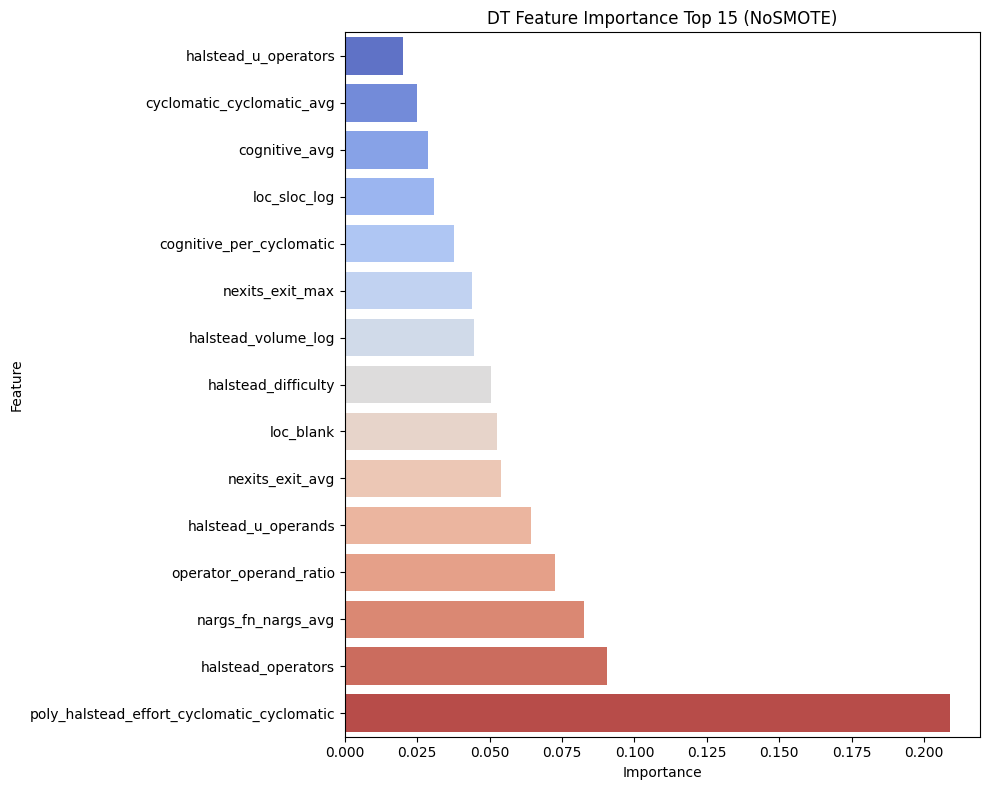

In [9]:
    # Block 1: Decision Tree WITHOUT SMOTE
    print("\n" + "="*60)
    print("BLOCK 1: DECISION TREE WITHOUT SMOTE")
    print("="*60)
    dt_clf_no_smote, dt_params_no_smote, dt_res_no_smote = train_model(
        X_train_final, y_train_encoded, 'dt', False, cv, le, MODEL_OUTPUT_DIR)


BLOCK 2: DECISION TREE WITH SMOTE

SMOTE - DT
Best params: {'dt__class_weight': {0: 1, 1: 3}, 'dt__criterion': 'gini', 'dt__max_depth': 15, 'dt__min_samples_leaf': 20, 'dt__min_samples_split': 50}
Best CV F1: 0.3505

DT 5-Fold CV Results:
Accuracy:  0.7120 +/- 0.0246
Precision: 0.2543 +/- 0.0174
Recall:    0.5668 +/- 0.0162
F1 Score:  0.3505 +/- 0.0162


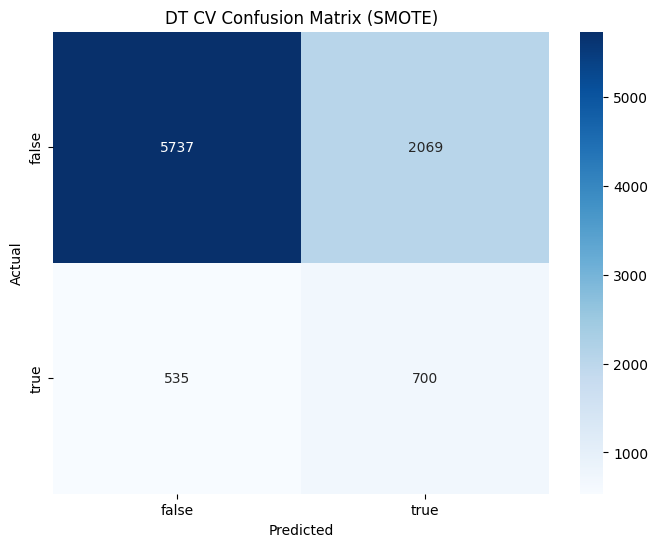


DT Feature Importances (top 15):
                                       feature  importance
8                              nexits_exit_max    0.314377
0                           nargs_fn_nargs_sum    0.144926
13                               cognitive_max    0.084824
7                              nexits_exit_avg    0.047683
27               poly_halstead_volume_loc_sloc    0.038035
15                        halstead_u_operators    0.037345
16                          halstead_operators    0.033349
20                      operator_operand_ratio    0.032285
1                      nargs_closure_nargs_sum    0.030910
4                           nargs_fn_nargs_max    0.029679
19                                   loc_blank    0.027647
11                               cognitive_avg    0.026017
3                      nargs_closure_nargs_avg    0.023284
25  poly_halstead_effort_cyclomatic_cyclomatic    0.019609
21                    cognitive_per_cyclomatic    0.018698


/tmp/ipykernel_188412/920718442.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top15, palette=colors)


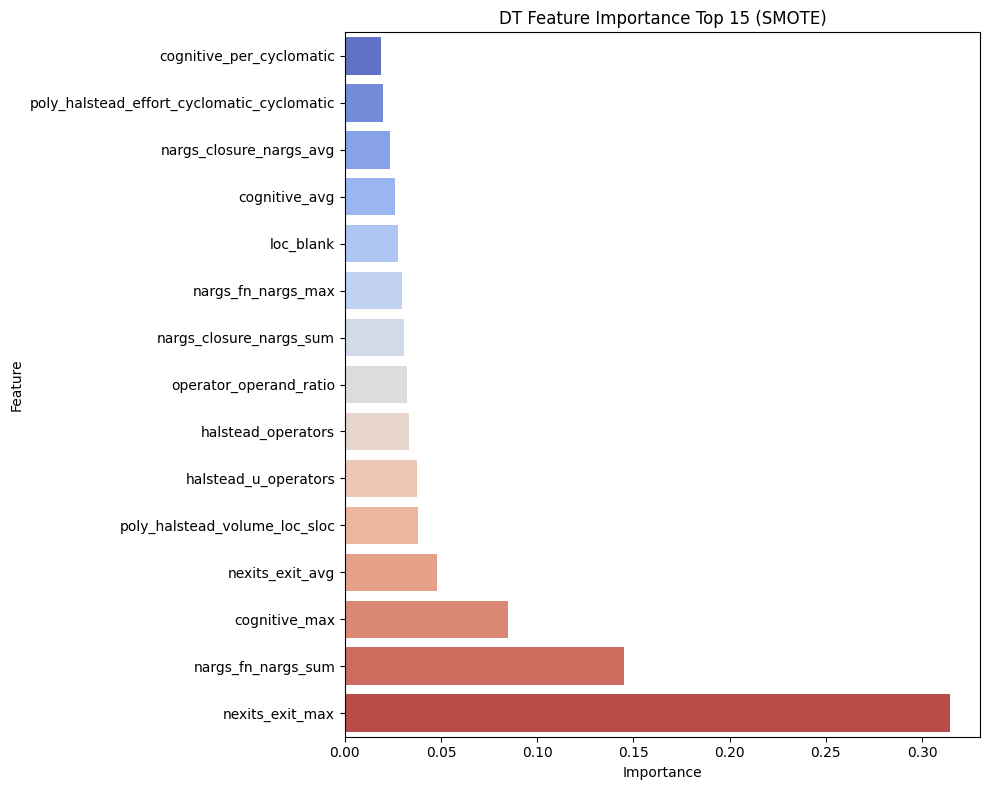

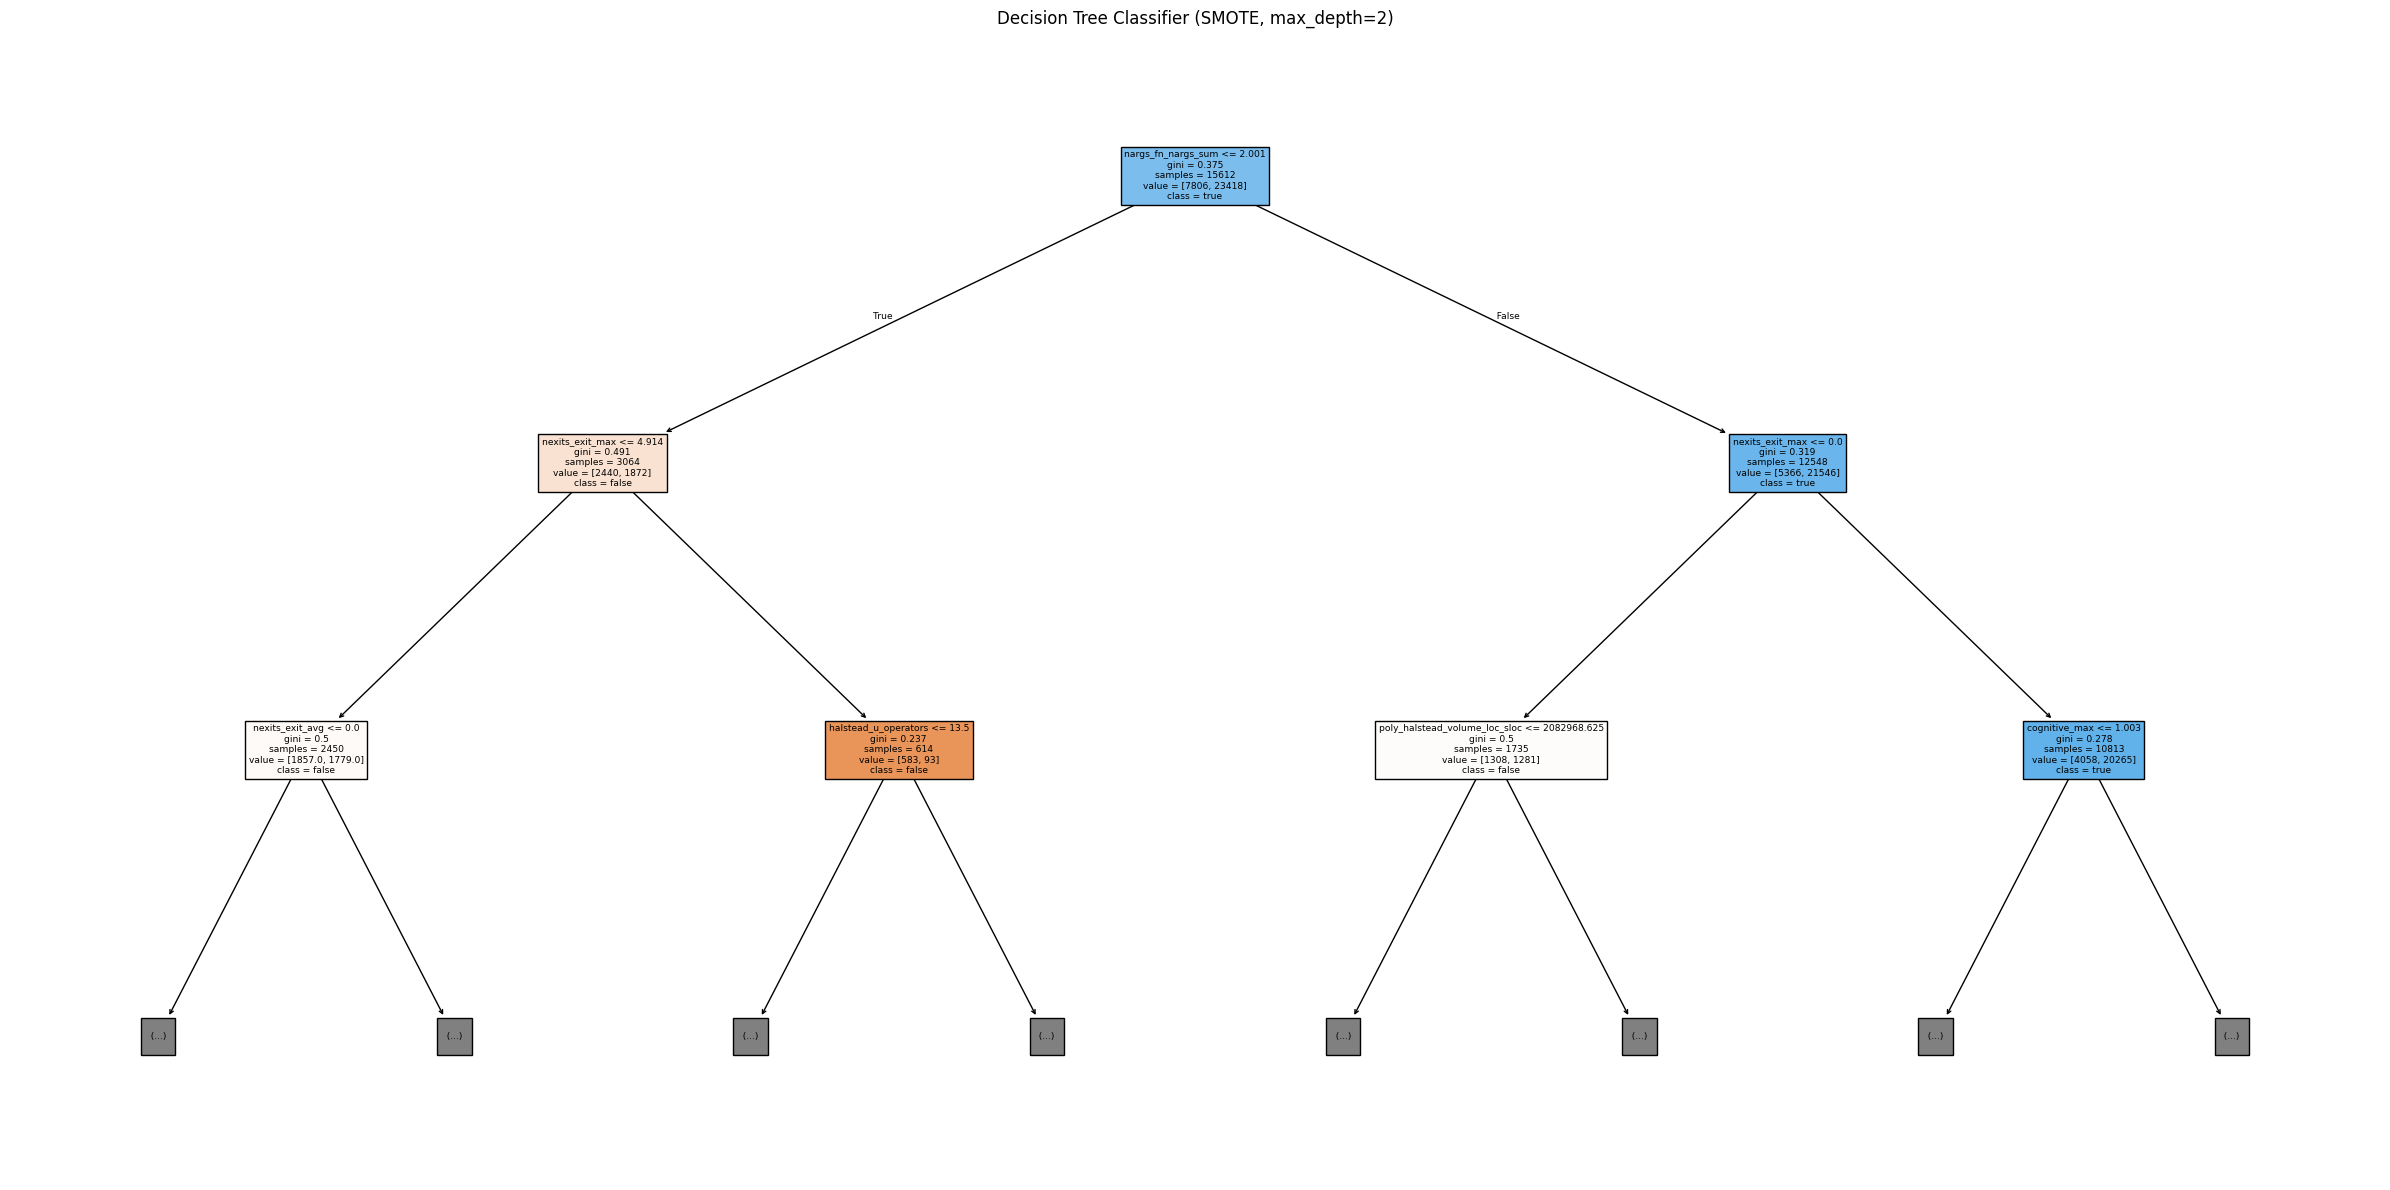

Decision Tree Rules (SMOTE, first 4 levels):
|--- nargs_fn_nargs_sum <= 2.00
|   |--- nexits_exit_max <= 4.91
|   |   |--- nexits_exit_avg <= 0.00
|   |   |   |--- halstead_difficulty <= 70.86
|   |   |   |   |--- nargs_fn_nargs_avg <= 0.18
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- nargs_fn_nargs_avg >  0.18
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- halstead_difficulty >  70.86
|   |   |   |   |--- class: 1
|   |   |--- nexits_exit_avg >  0.00
|   |   |   |--- nexits_exit_max <= 1.00
|   |   |   |   |--- class: 1
|   |   |   |--- nexits_exit_max >  1.00
|   |   |   |   |--- nexits_exit_max <= 1.00
|   |   |   |   |   |--- truncated branch of depth 11
|   |   |   |   |--- nexits_exit_max >  1.00
|   |   |   |   |   |--- truncated branch of depth 9
|   |--- nexits_exit_max >  4.91
|   |   |--- halstead_u_operators <= 13.50
|   |   |   |--- class: 1
|   |   |--- halstead_u_operators >  13.50
|   |   |   |--- nexits_exit_avg <= 2.

In [10]:
    # Block 2: Decision Tree WITH SMOTE
    print("\n" + "="*60)
    print("BLOCK 2: DECISION TREE WITH SMOTE")
    print("="*60)
    dt_clf_smote, dt_params_smote, dt_res_smote = train_model(
        X_train_final, y_train_encoded, 'dt', True, cv, le, MODEL_OUTPUT_DIR)

    fig, ax = plt.subplots(figsize=(24, 12))
    plot_tree(dt_clf_smote.named_steps['dt'], feature_names=list(X_train_final.columns),
              class_names=list(le.classes_), filled=True, ax=ax, max_depth=2)
    plt.title("Decision Tree Classifier (SMOTE, max_depth=2)")
    plt.tight_layout()
    plt.savefig("decision_tree_optimized_smote.png", dpi=150, bbox_inches='tight')
    plt.show()

    tree_rules = export_text(
        dt_clf_smote.named_steps['dt'], feature_names=list(X_train_final.columns), max_depth=4)
    print("Decision Tree Rules (SMOTE, first 4 levels):")
    print(tree_rules)


BLOCK 3: RANDOM FOREST WITHOUT SMOTE

NO SMOTE - RF
Best params: {'rf__class_weight': {0: 1, 1: 10}, 'rf__max_depth': 15, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 8, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}
Best CV F1: 0.4161

RF 5-Fold CV Results:
Accuracy:  0.8119 +/- 0.0063
Precision: 0.3614 +/- 0.0135
Recall:    0.4907 +/- 0.0173
F1 Score:  0.4161 +/- 0.0129


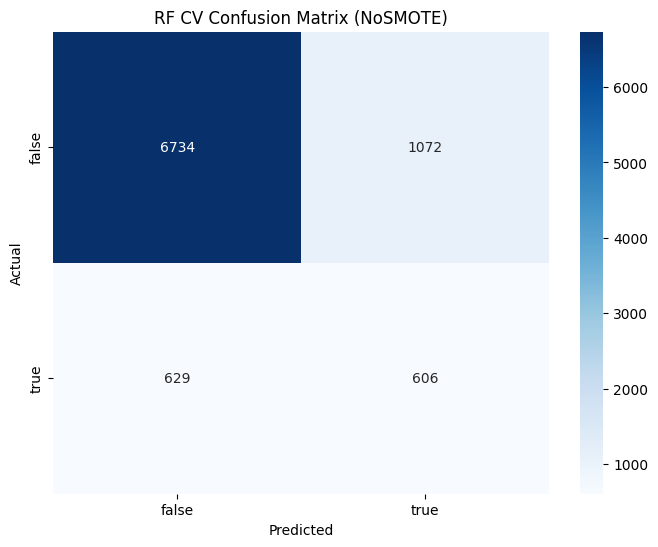


RF Feature Importances (top 15):
                                       feature  importance
25  poly_halstead_effort_cyclomatic_cyclomatic    0.072816
16                          halstead_operators    0.065104
22                         halstead_volume_log    0.064379
20                      operator_operand_ratio    0.060012
18                         halstead_difficulty    0.057440
23                                loc_sloc_log    0.053953
2                           nargs_fn_nargs_avg    0.053806
17                         halstead_u_operands    0.050790
27               poly_halstead_volume_loc_sloc    0.050146
7                              nexits_exit_avg    0.050134
15                        halstead_u_operators    0.049490
19                                   loc_blank    0.045480
0                           nargs_fn_nargs_sum    0.041755
21                    cognitive_per_cyclomatic    0.038655
10                               cognitive_sum    0.037466


/tmp/ipykernel_188412/920718442.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top15, palette=colors)


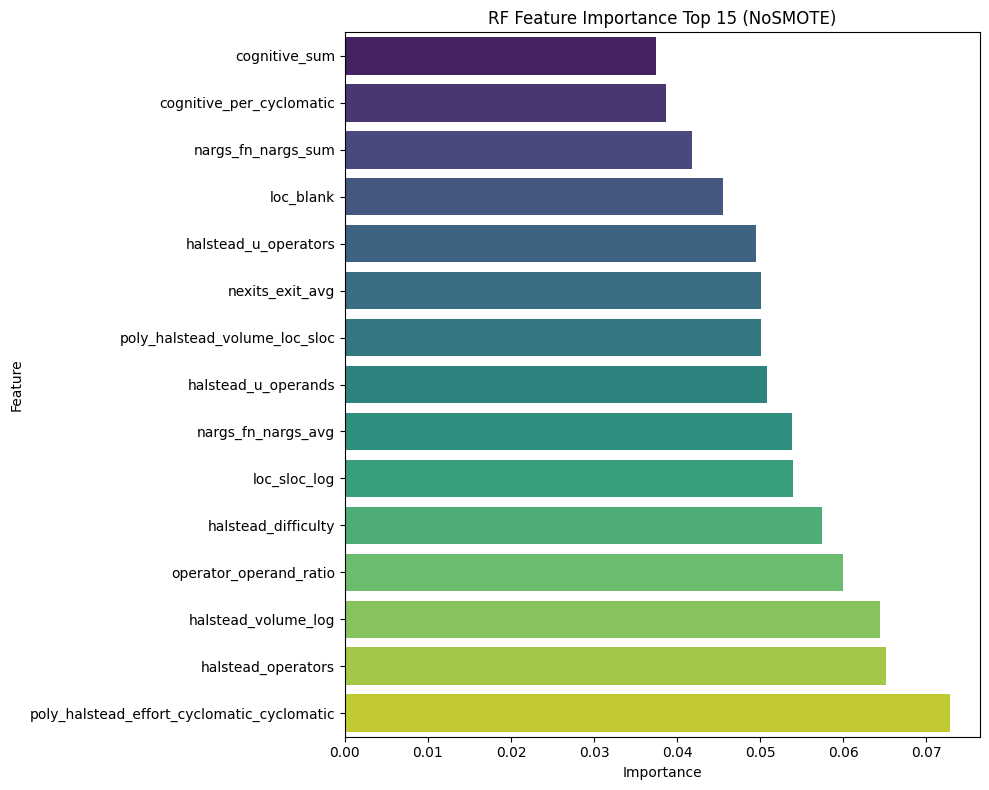

In [11]:
    # Block 3: Random Forest WITHOUT SMOTE
    print("\n" + "="*60)
    print("BLOCK 3: RANDOM FOREST WITHOUT SMOTE")
    print("="*60)
    rf_clf_no_smote, rf_params_no_smote, rf_res_no_smote = train_model(
        X_train_final, y_train_encoded, 'rf', False, cv, le, MODEL_OUTPUT_DIR)


BLOCK 4: RANDOM FOREST WITH SMOTE

SMOTE - RF
Best params: {'rf__class_weight': {0: 1, 1: 3}, 'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}
Best CV F1: 0.4333

RF 5-Fold CV Results:
Accuracy:  0.8109 +/- 0.0099
Precision: 0.3674 +/- 0.0200
Recall:    0.5287 +/- 0.0204
F1 Score:  0.4333 +/- 0.0180


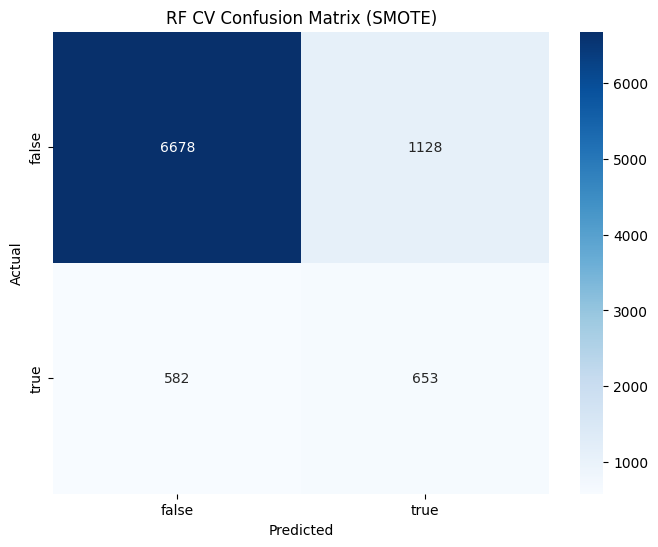


RF Feature Importances (top 15):
                                       feature  importance
25  poly_halstead_effort_cyclomatic_cyclomatic    0.068415
22                         halstead_volume_log    0.065856
16                          halstead_operators    0.064220
20                      operator_operand_ratio    0.063315
23                                loc_sloc_log    0.058228
18                         halstead_difficulty    0.055983
27               poly_halstead_volume_loc_sloc    0.055812
19                                   loc_blank    0.053759
17                         halstead_u_operands    0.052390
2                           nargs_fn_nargs_avg    0.050612
15                        halstead_u_operators    0.044843
7                              nexits_exit_avg    0.043184
0                           nargs_fn_nargs_sum    0.041563
21                    cognitive_per_cyclomatic    0.039442
10                               cognitive_sum    0.038765


/tmp/ipykernel_188412/920718442.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top15, palette=colors)


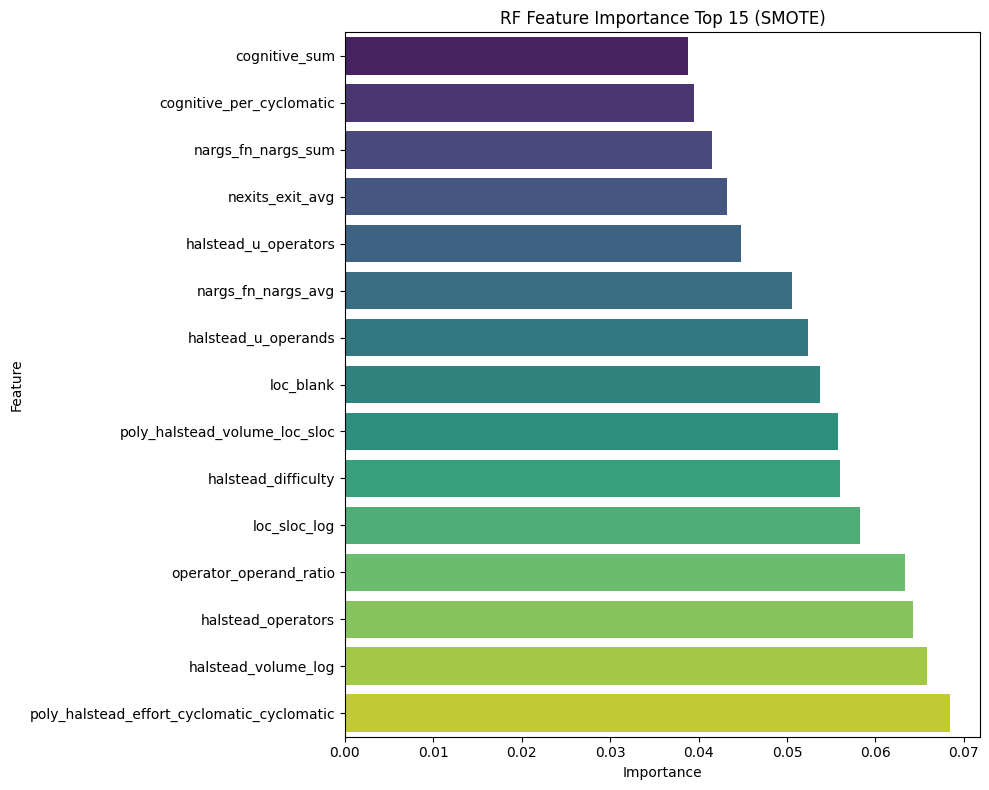

In [12]:
    # Block 4: Random Forest WITH SMOTE
    print("\n" + "="*60)
    print("BLOCK 4: RANDOM FOREST WITH SMOTE")
    print("="*60)
    rf_clf_smote, rf_params_smote, rf_res_smote = train_model(
        X_train_final, y_train_encoded, 'rf', True, cv, le, MODEL_OUTPUT_DIR)

In [17]:
print("\n" + "="*60)
print("OPTIMIZED RANDOM FOREST RULE EXTRACTION (te2rules)")
print("="*60)

all_features = list(X_train_final.columns)

_, X_sub, _, y_sub = train_test_split(
    X_train_final,
    y_train_encoded,
    test_size=2000,
    stratify=y_train_encoded,
    random_state=42
)

explainer = ModelExplainer(
    model=rf_clf.named_steps['rf'],
    feature_names=all_features
)

print(f"Extracting rules using {len(all_features)} features and {len(X_sub)} samples...")
rf_rules = explainer.explain(X_sub.values, y_sub)

results = []

for rule in rf_rules:
    query_string = rule.replace('&', 'and')

    try:
        matches = X_sub.query(query_string)
        support = len(matches)

        if support > 0:
            matching_labels = y_sub[matches.index]
            precision = (matching_labels == 1).mean()

            results.append({
                'rule': rule,
                'support': support,
                'precision': precision,
                'coverage_pct': (support / len(X_sub)) * 100
            })
    except Exception as e:
        continue 

    

# Run the evaluation

# Display settings and results
pd.set_option('display.max_colwidth', None)
print(f"Total Rules Extracted: {len(rf_rules)}")
print("\nTop 5 Most Important Rules (by Support):")
print(pd.DataFrame(results).sort_values(by='support', ascending=False).head(5))


OPTIMIZED RANDOM FOREST RULE EXTRACTION (te2rules)
Extracting rules using 30 features and 2000 samples...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 520204/520204 [00:00<00:00, 570113.00it/s]


Total Rules Extracted: 83

Top 5 Most Important Rules (by Support):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    rule  \
4         cognitive_avg > 3.502742886543274 & cognitive_max > 8.72629690170288 & cognitive_per_cyclomatic <= 3.3673081398010254 & cognitive_sum > 1.0019041299819946 & halstead_difficulty > 105.43690872192383 & halstead_u_operands <=


MODEL COMPARISON (CV-BASED)


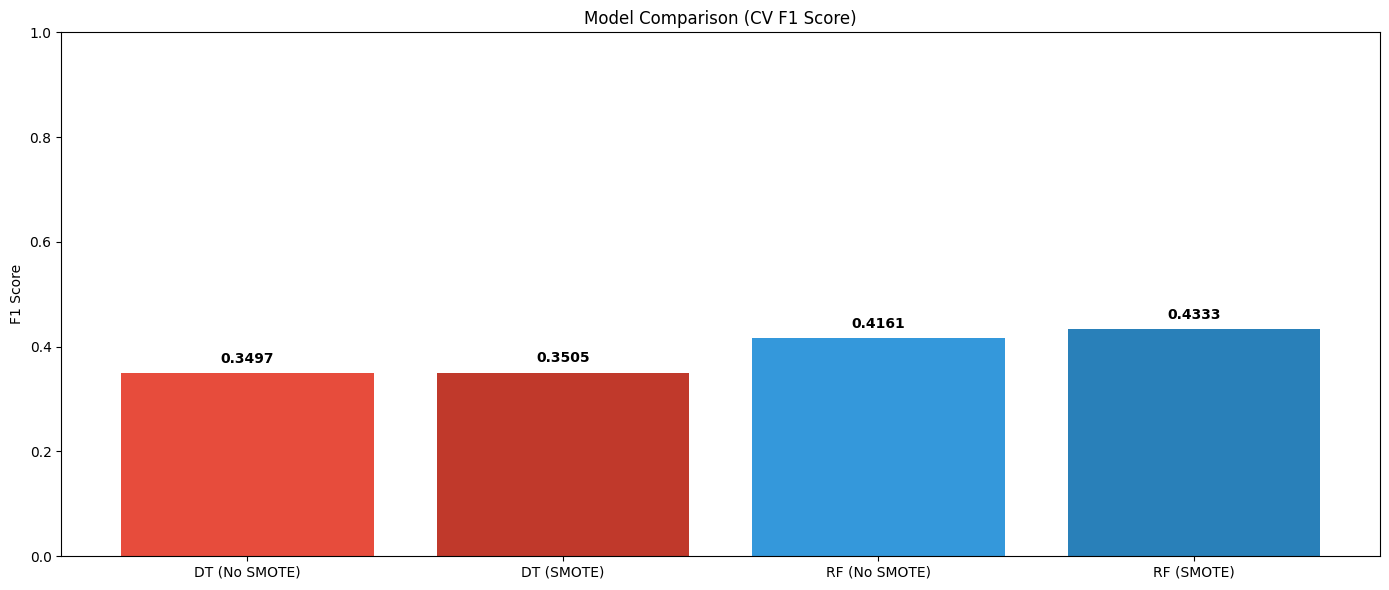


SUMMARY
Original features: 100
Enhanced features: 100
Selected features: 30

Decision Tree CV F1 (No SMOTE): 0.3497
Decision Tree CV F1 (SMOTE):    0.3505
Random Forest CV F1 (No SMOTE): 0.4161
Random Forest CV F1 (SMOTE):    0.4333

OPTIMIZATION COMPLETE

Final Feature Set:
['nargs_fn_nargs_sum', 'nargs_closure_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_max', 'nexits_exit', 'nexits_exit_sum', 'nexits_exit_avg', 'nexits_exit_max', 'cognitive', 'cognitive_sum', 'cognitive_avg', 'cognitive_min', 'cognitive_max', 'cyclomatic_cyclomatic_avg', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_difficulty', 'loc_blank', 'operator_operand_ratio', 'cognitive_per_cyclomatic', 'halstead_volume_log', 'loc_sloc_log', 'poly_halstead_difficulty_nom_functions', 'poly_halstead_effort_cyclomatic_cyclomatic', 'poly_halstead_effort_nom_functions', 'poly_halstead_volume_loc_sloc', 'poly_cyclomatic_cyclomatic_nom_functions', 'poly_nom_functions

In [13]:
    print("\n" + "="*60)
    print("MODEL COMPARISON (CV-BASED)")
    print("="*60)

    plt.figure(figsize=(14, 6))
    models = ['DT (No SMOTE)', 'DT (SMOTE)', 'RF (No SMOTE)', 'RF (SMOTE)']
    cv_f1_scores = [
        dt_res_no_smote['f1'],
        dt_res_smote['f1'],
        rf_res_no_smote['f1'],
        rf_res_smote['f1']
    ]
    colors = ['#e74c3c', '#c0392b', '#3498db', '#2980b9']

    plt.bar(models, cv_f1_scores, color=colors)
    plt.ylabel('F1 Score')
    plt.title('Model Comparison (CV F1 Score)')
    plt.ylim(0, 1)
    for i, v in enumerate(cv_f1_scores):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Original features: {X_train.shape[1]}")
    print(f"Enhanced features: {X_train.shape[1]}")
    print(f"Selected features: {X_train_final.shape[1]}")

    print(f"\nDecision Tree CV F1 (No SMOTE): {dt_res_no_smote['f1']:.4f}")
    print(f"Decision Tree CV F1 (SMOTE):    {dt_res_smote['f1']:.4f}")
    print(f"Random Forest CV F1 (No SMOTE): {rf_res_no_smote['f1']:.4f}")
    print(f"Random Forest CV F1 (SMOTE):    {rf_res_smote['f1']:.4f}")

    print("\n" + "="*60)
    print("OPTIMIZATION COMPLETE")
    print("="*60)

    print("\nFinal Feature Set:")
    print(X_train_final.columns.tolist())

In [14]:
df_val = pd.read_csv(VAL_CSV)
print(f"Validation data: {df_val.shape[0]} samples")

X_val, y_val, _ = engineer_features(df_val)
print(f"Validation feature engineered: {X_val.shape}")

Validation data: 876 samples
Validation feature engineered: (872, 100)



VALIDATION ON HELD-OUT DATASET
Target classes: ['false' 'true']
Validation features: (872, 30)

Validation Metrics (RF with SMOTE):
Accuracy:  0.8096
Precision: 0.5152
Recall:    0.6879
F1 Score:  0.5891

Confusion Matrix:
[[587 112]
 [ 54 119]]


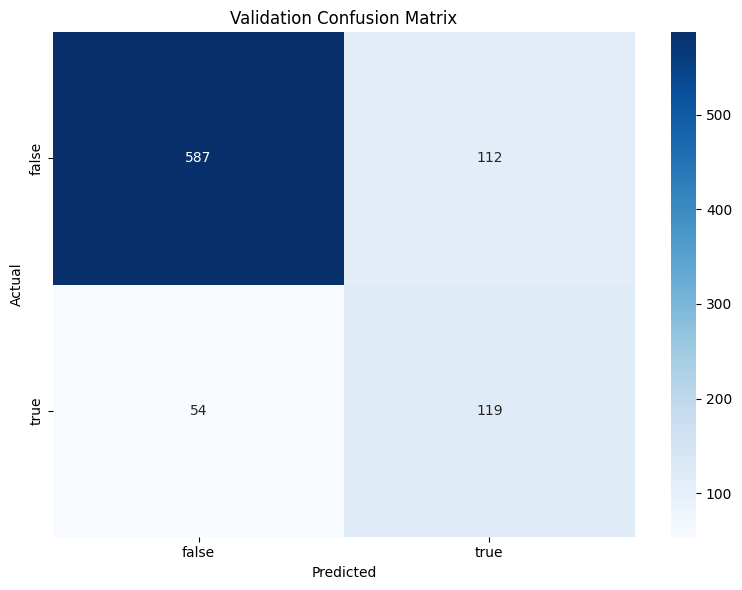

Confusion matrix saved to ../../results/acts_validation_predictions.png
